Datenpunkte: 30401
Wellenzahlbereich: 200.0 – 4000.0 cm⁻¹
Gespeichert: spektrum_plots.png


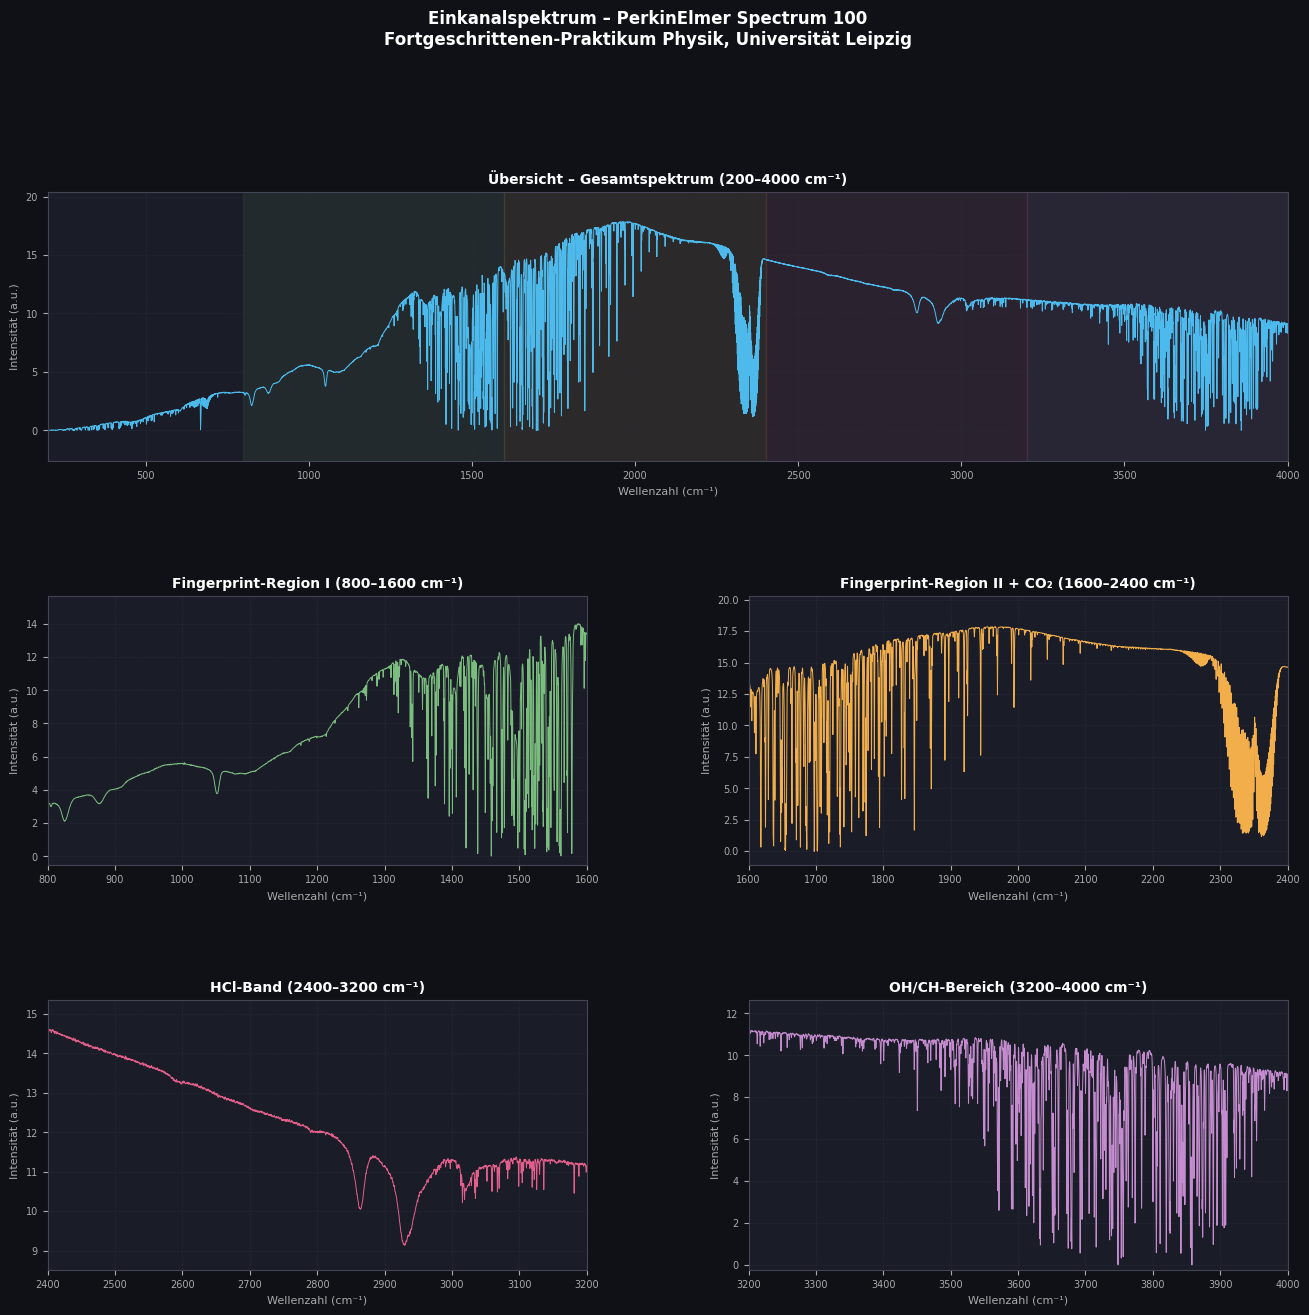

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Datei einlesen ────────────────────────────────────────────────────────────
DATEI = "1_1_1.asc"

wellenzahl = []
intensitaet = []

with open(DATEI, "r", encoding="latin-1") as f:
    daten_abschnitt = False
    for zeile in f:
        zeile = zeile.strip()
        if zeile == "#DATA":
            daten_abschnitt = True
            continue
        if daten_abschnitt and zeile:
            teile = zeile.split()
            if len(teile) == 2:
                try:
                    wellenzahl.append(float(teile[0]))
                    intensitaet.append(float(teile[1]))
                except ValueError:
                    pass

wn = np.array(wellenzahl)
it = np.array(intensitaet)

# Aufsteigend sortieren (Datei läuft von 4000 → 200)
sortierung = np.argsort(wn)
wn = wn[sortierung]
it = it[sortierung]

print(f"Datenpunkte: {len(wn)}")
print(f"Wellenzahlbereich: {wn.min():.1f} – {wn.max():.1f} cm⁻¹")

# ── Plotbereiche definieren ───────────────────────────────────────────────────
# Übersicht + 5 Zoombereiche die interessante Regionen abdecken
bereiche = [
    (200,  4000, "Übersicht – Gesamtspektrum"),
    (200,  800,  "Ferninfrarot-Rand / FIR-Bereich"),
    (800,  1600, "Fingerprint-Region I"),
    (1600, 2400, "Fingerprint-Region II + CO₂-Bande"),
    (2400, 3200, "HCl-Rotations-Schwingungsband"),
    (3200, 4000, "OH / CH-Streckschwingungen"),
]

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor("#0f1117")

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.30)

axes = [
    fig.add_subplot(gs[0, :]),   # Übersicht – volle Breite
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[2, 1]),
]

# Sechsten Plot separat (letztes Detail)
# Wir passen das Layout an: 3 Zeilen, erste Zeile voll, Rest 2×2
# → 5 Achsen reichen, letzten Bereich in gs[2,1] einfügen – wir brauchen 6
# Neue Lösung: 3×2 Grid, alle 6 Felder nutzen, Übersicht über beide Spalten via colspan

fig.clear()
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.30)

ax_uebersicht = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[2, 1])

alle_axes = [ax_uebersicht, ax1, ax2, ax3, ax4]

# 5 Bereiche: Übersicht + 4 Zoom-Fenster
bereiche_plot = [
    (200,  4000, "Übersicht – Gesamtspektrum (200–4000 cm⁻¹)"),
    (800,  1600, "Fingerprint-Region I (800–1600 cm⁻¹)"),
    (1600, 2400, "Fingerprint-Region II + CO₂ (1600–2400 cm⁻¹)"),
    (2400, 3200, "HCl-Band (2400–3200 cm⁻¹)"),
    (3200, 4000, "OH/CH-Bereich (3200–4000 cm⁻¹)"),
]

farben = ["#4fc3f7", "#81c784", "#ffb74d", "#f06292", "#ce93d8"]

for ax, (x_min, x_max, titel), farbe in zip(alle_axes, bereiche_plot, farben):
    maske = (wn >= x_min) & (wn <= x_max)
    x_plot = wn[maske]
    y_plot = it[maske]

    ax.set_facecolor("#1a1d27")
    ax.plot(x_plot, y_plot, color=farbe, linewidth=0.7, alpha=0.95)

    # Y-Achse sinnvoll begrenzen (Ausreißer abschneiden)
    p2, p98 = np.percentile(y_plot, [1, 99])
    marge = (p98 - p2) * 0.15
    ax.set_ylim(p2 - marge, p98 + marge)
    ax.set_xlim(x_min, x_max)

    ax.set_title(titel, color="white", fontsize=10, pad=6, fontweight="bold")
    ax.set_xlabel("Wellenzahl (cm⁻¹)", color="#aaaaaa", fontsize=8)
    ax.set_ylabel("Intensität (a.u.)", color="#aaaaaa", fontsize=8)
    ax.tick_params(colors="#aaaaaa", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444455")

    # Gitternetz
    ax.grid(True, color="#2a2d3a", linewidth=0.5, linestyle="--", alpha=0.7)

    # Im Übersichtsplot: Zoom-Bereiche als farbige Rechtecke andeuten
    if x_min == 200 and x_max == 4000:
        zoom_bereiche = [
            (800,  1600, farben[1]),
            (1600, 2400, farben[2]),
            (2400, 3200, farben[3]),
            (3200, 4000, farben[4]),
        ]
        for zx1, zx2, zf in zoom_bereiche:
            ax.axvspan(zx1, zx2, alpha=0.08, color=zf)

fig.suptitle(
    "Einkanalspektrum – PerkinElmer Spectrum 100\nFortgeschrittenen-Praktikum Physik, Universität Leipzig",
    color="white", fontsize=12, fontweight="bold", y=1.01
)

plt.savefig(
    "spektrum_plots.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
print("Gespeichert: spektrum_plots.png")
plt.show()

Fertig.


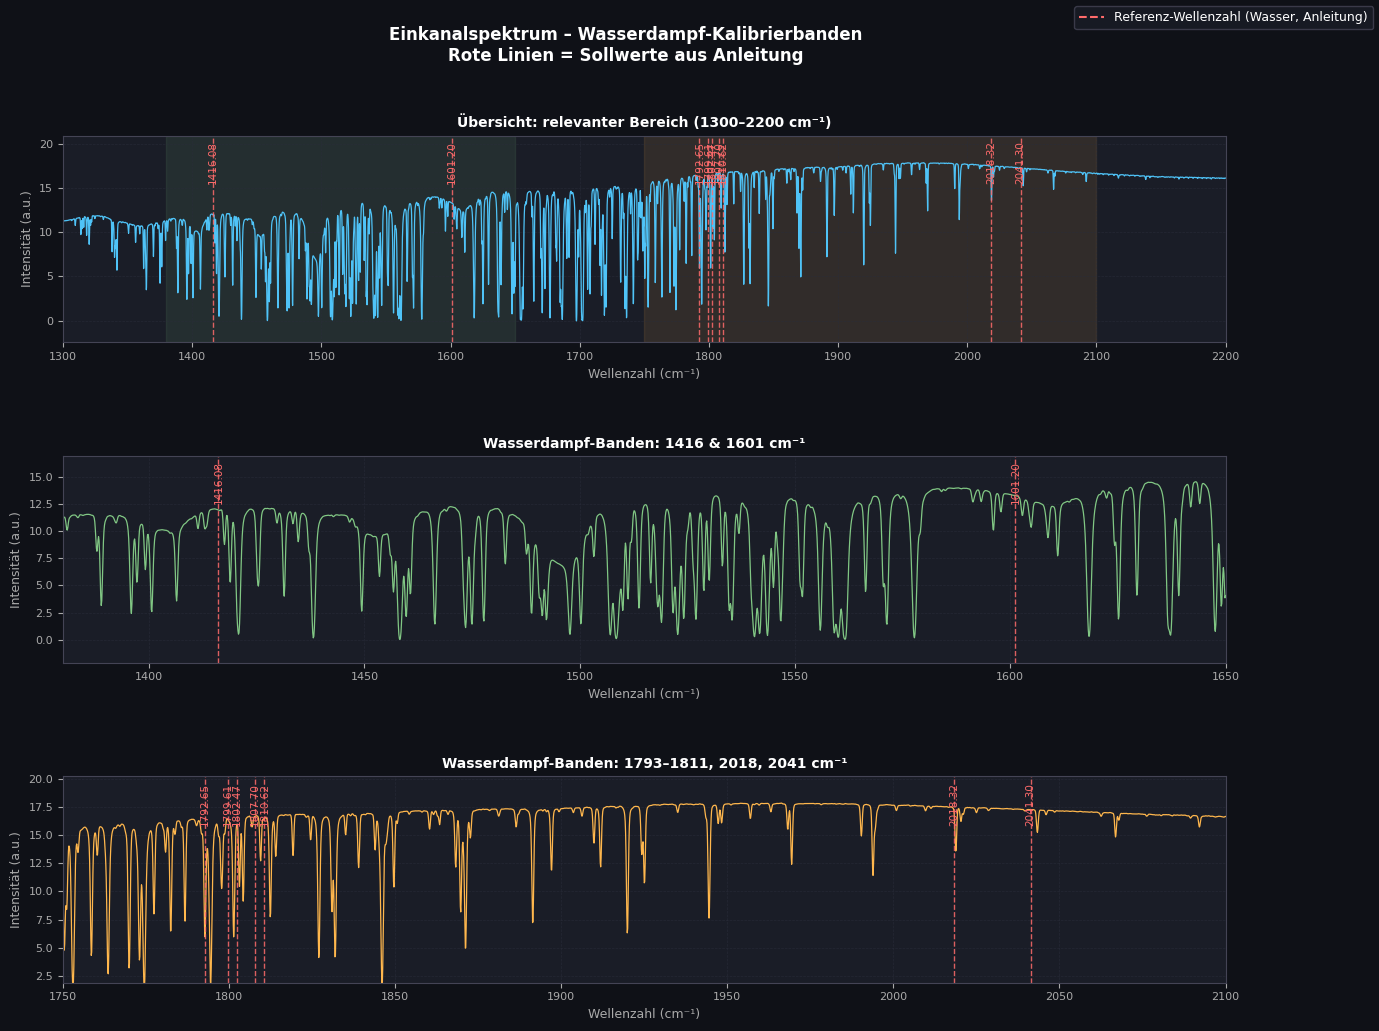

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Datei einlesen ────────────────────────────────────────────────────────────
DATEI = "1_1_1.asc"

wellenzahl = []
intensitaet = []

with open(DATEI, "r", encoding="latin-1") as f:
    daten = False
    for zeile in f:
        zeile = zeile.strip()
        if zeile == "#DATA":
            daten = True
            continue
        if daten and zeile:
            teile = zeile.split()
            if len(teile) == 2:
                try:
                    wellenzahl.append(float(teile[0]))
                    intensitaet.append(float(teile[1]))
                except ValueError:
                    pass

wn = np.array(wellenzahl)
it = np.array(intensitaet)
sortierung = np.argsort(wn)
wn = wn[sortierung]
it = it[sortierung]

# ── Wasserdampf-Referenzwellenzahlen aus der Anleitung ───────────────────────
wasser_linien = [1416.08, 1601.20, 1792.65, 1799.61, 1802.47,
                 1807.70, 1810.62, 2018.32, 2041.30]

# ── Zwei Zoom-Bereiche mit etwas Puffer ──────────────────────────────────────
# Region 1: 1380–1650  (deckt 1416 und 1601 ab)
# Region 2: 1750–2100  (deckt alle dicht gepackten Linien + 2018 + 2041 ab)
bereiche = [
    (1380, 1650,  "Wasserdampf-Banden: 1416 & 1601 cm⁻¹"),
    (1750, 2100,  "Wasserdampf-Banden: 1793–1811, 2018, 2041 cm⁻¹"),
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 11))
fig.patch.set_facecolor("#0f1117")

gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.55)

# Übersicht oben
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

alle_axes   = [ax0,     ax1,          ax2]
alle_ber    = [(1300, 2200, "Übersicht: relevanter Bereich (1300–2200 cm⁻¹)")] + bereiche
alle_farben = ["#4fc3f7", "#81c784", "#ffb74d"]

for ax, (x1, x2, titel), farbe in zip(alle_axes, alle_ber, alle_farben):
    maske  = (wn >= x1) & (wn <= x2)
    xp, yp = wn[maske], it[maske]

    ax.set_facecolor("#1a1d27")
    ax.plot(xp, yp, color=farbe, linewidth=0.9)

    # Y-Grenzen
    p1, p99 = np.percentile(yp, [1, 99])
    marge = (p99 - p1) * 0.18
    ax.set_ylim(p1 - marge, p99 + marge)
    ax.set_xlim(x1, x2)

    # Referenzlinien einzeichnen
    for linie in wasser_linien:
        if x1 <= linie <= x2:
            ax.axvline(linie, color="#ff6b6b", linewidth=1.0,
                       linestyle="--", alpha=0.85)
            # Label oben im Plot
            y_text = ax.get_ylim()[1] * 0.97
            ax.text(linie, y_text, f"{linie:.2f}",
                    color="#ff6b6b", fontsize=7.5, ha="center", va="top",
                    rotation=90)

    ax.set_title(titel, color="white", fontsize=10, pad=6, fontweight="bold")
    ax.set_xlabel("Wellenzahl (cm⁻¹)", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Intensität (a.u.)", color="#aaaaaa", fontsize=9)
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444455")
    ax.grid(True, color="#2a2d3a", linewidth=0.5, linestyle="--", alpha=0.7)

    # Im Übersichts-Plot: Zoom-Bereiche farbig markieren
    if x1 == 1300:
        ax.axvspan(1380, 1650, alpha=0.10, color="#81c784")
        ax.axvspan(1750, 2100, alpha=0.10, color="#ffb74d")

# Legende für die roten Linien
from matplotlib.lines import Line2D
legende = [Line2D([0], [0], color="#ff6b6b", linewidth=1.5,
                  linestyle="--", label="Referenz-Wellenzahl (Wasser, Anleitung)")]
fig.legend(handles=legende, loc="upper right",
           facecolor="#1a1d27", edgecolor="#444455",
           labelcolor="white", fontsize=9)

fig.suptitle(
    "Einkanalspektrum – Wasserdampf-Kalibrierbanden\n"
    "Rote Linien = Sollwerte aus Anleitung",
    color="white", fontsize=12, fontweight="bold"
)

plt.savefig("wasser_kalibrierung.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Fertig.")

Fertig.


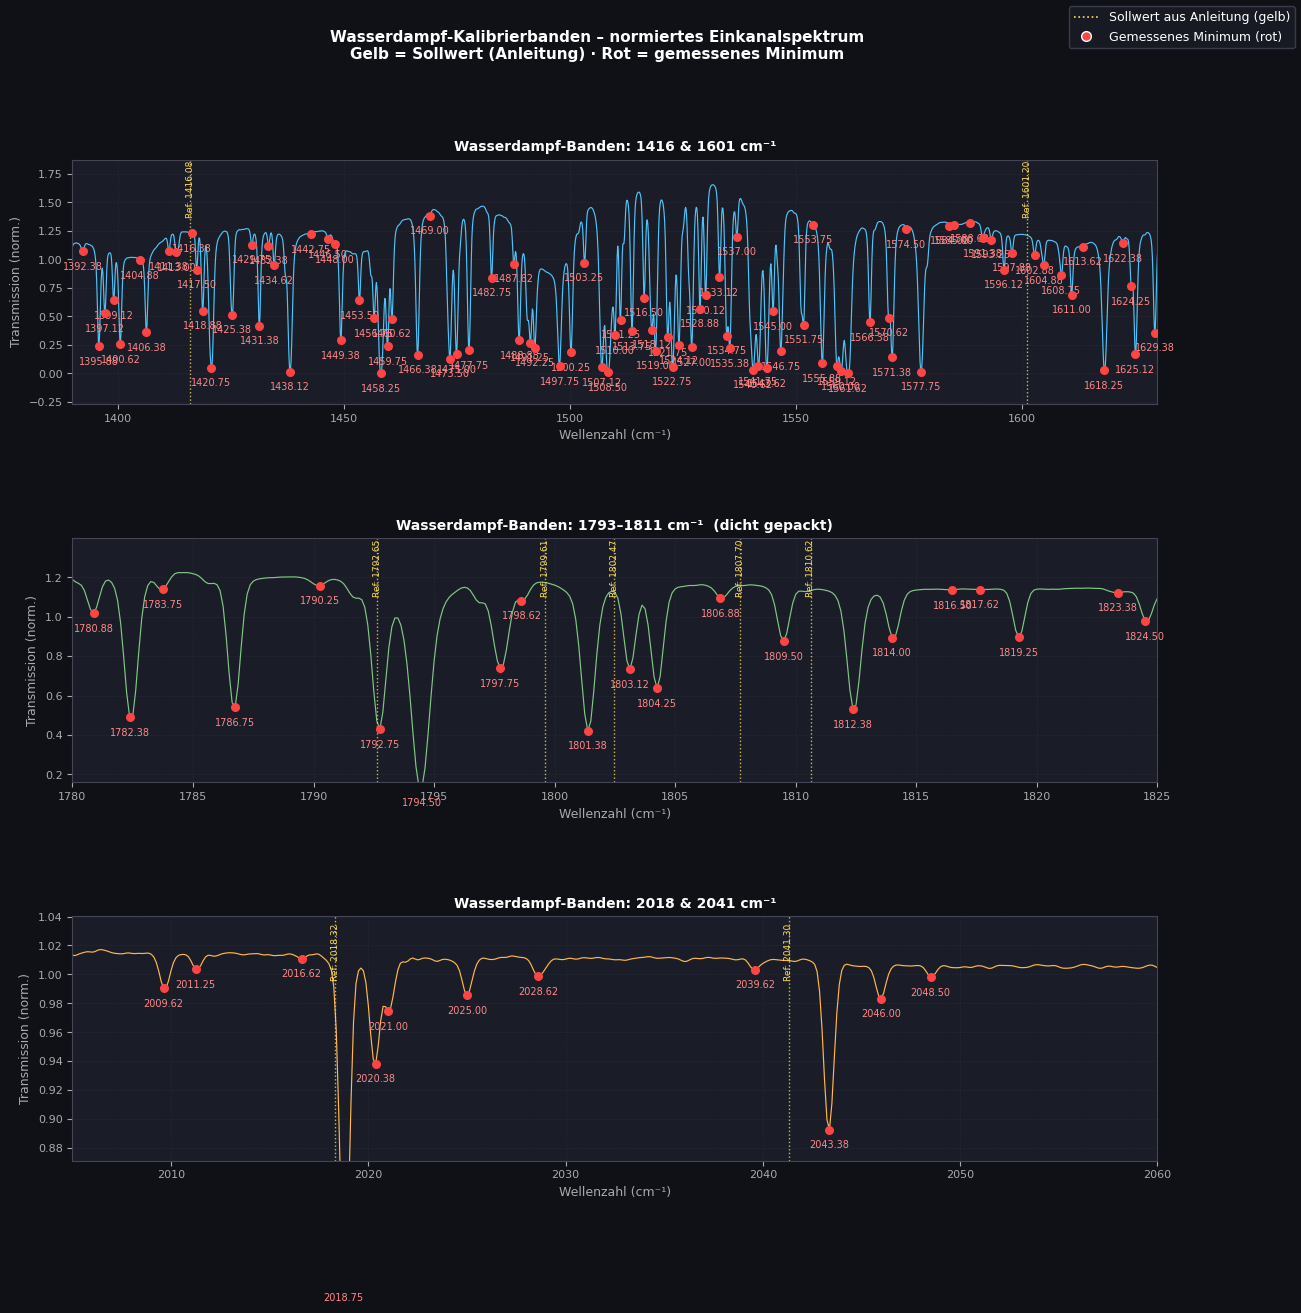

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

# ── Datei einlesen ────────────────────────────────────────────────────────────
DATEI = "1_1_1.asc"

wn_list, it_list = [], []
with open(DATEI, "r", encoding="latin-1") as f:
    daten = False
    for zeile in f:
        z = zeile.strip()
        if z == "#DATA":
            daten = True; continue
        if daten and z:
            t = z.split()
            if len(t) == 2:
                try:
                    wn_list.append(float(t[0]))
                    it_list.append(float(t[1]))
                except ValueError:
                    pass

wn = np.array(wn_list)
it = np.array(it_list)
idx = np.argsort(wn)
wn, it = wn[idx], it[idx]

# ── Untergrund entfernen: sehr breit geglättete Kurve als "Background" ────────
# Fenstergröße ~800 Punkte entspricht ~100 cm⁻¹ – glättet alle scharfen Linien weg
untergrund = uniform_filter1d(it, size=800)
# Transmissions-ähnliche Kurve: Abweichung vom Untergrund
transmission = it / untergrund  # Werte ~1 außerhalb von Linien, Dips wo Absorption

# ── Referenzwellenzahlen Wasserdampf aus Anleitung ───────────────────────────
wasser_ref = {
    1416.08: "1416.08",
    1601.20: "1601.20",
    1792.65: "1792.65",
    1799.61: "1799.61",
    1802.47: "1802.47",
    1807.70: "1807.70",
    1810.62: "1810.62",
    2018.32: "2018.32",
    2041.30: "2041.30",
}

# ── Zoom-Bereiche passend zu den Referenzlinien ───────────────────────────────
bereiche = [
    (1390, 1630,  "Wasserdampf-Banden: 1416 & 1601 cm⁻¹"),
    (1780, 1825,  "Wasserdampf-Banden: 1793–1811 cm⁻¹  (dicht gepackt)"),
    (2005, 2060,  "Wasserdampf-Banden: 2018 & 2041 cm⁻¹"),
]

# ── Minima in jedem Bereich automatisch finden ───────────────────────────────
def finde_minima(wn, trans, x1, x2, prominenz=0.003, abstand=3):
    maske = (wn >= x1) & (wn <= x2)
    x, y = wn[maske], trans[maske]
    # Minima = Peaks in -y
    peaks, props = find_peaks(-y, prominence=prominenz, distance=abstand)
    return x[peaks], y[peaks]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 13))
fig.patch.set_facecolor("#0f1117")
gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.55)

farben_kurve = ["#4fc3f7", "#81c784", "#ffb74d"]

for i, (ax_idx, (x1, x2, titel), farbe) in enumerate(
        zip(range(3), bereiche, farben_kurve)):

    ax = fig.add_subplot(gs[ax_idx])
    maske = (wn >= x1) & (wn <= x2)
    xp, yp = wn[maske], transmission[maske]

    ax.set_facecolor("#1a1d27")
    ax.plot(xp, yp, color=farbe, linewidth=0.85)

    # Y-Achse
    p1, p99 = np.percentile(yp, [1, 99])
    marge = (p99 - p1) * 0.20
    ax.set_ylim(p1 - marge, p99 + marge)
    ax.set_xlim(x1, x2)

    # Automatisch gefundene Minima als rote Punkte
    mx, my = finde_minima(wn, transmission, x1, x2)
    ax.scatter(mx, my, color="#ff4444", s=30, zorder=5)
    # Wellenzahl-Label an jedem Minimum
    for xi, yi in zip(mx, my):
        ax.text(xi, yi - (p99 - p1) * 0.06, f"{xi:.2f}",
                color="#ff8888", fontsize=7, ha="center", va="top")

    # Referenzlinien aus Anleitung
    for ref_wn, label in wasser_ref.items():
        if x1 <= ref_wn <= x2:
            ax.axvline(ref_wn, color="#ffdd57", linewidth=1.0,
                       linestyle=":", alpha=0.8)
            ax.text(ref_wn, ax.get_ylim()[1] * 0.995,
                    f"Ref: {label}", color="#ffdd57", fontsize=6.5,
                    ha="center", va="top", rotation=90)

    ax.set_title(titel, color="white", fontsize=10, pad=6, fontweight="bold")
    ax.set_xlabel("Wellenzahl (cm⁻¹)", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Transmission (norm.)", color="#aaaaaa", fontsize=9)
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444455")
    ax.grid(True, color="#2a2d3a", linewidth=0.5, linestyle="--", alpha=0.7)

# Legende
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legende = [
    Line2D([0], [0], color="#ffdd57", linewidth=1.2, linestyle=":",
           label="Sollwert aus Anleitung (gelb)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff4444",
           markersize=7, label="Gemessenes Minimum (rot)", linestyle="None"),
]
fig.legend(handles=legende, loc="upper right", facecolor="#1a1d27",
           edgecolor="#444455", labelcolor="white", fontsize=9)

fig.suptitle(
    "Wasserdampf-Kalibrierbanden – normiertes Einkanalspektrum\n"
    "Gelb = Sollwert (Anleitung) · Rot = gemessenes Minimum",
    color="white", fontsize=11, fontweight="bold"
)

plt.savefig("wasser_kalibrierung_v2.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Fertig.")

Fertig.


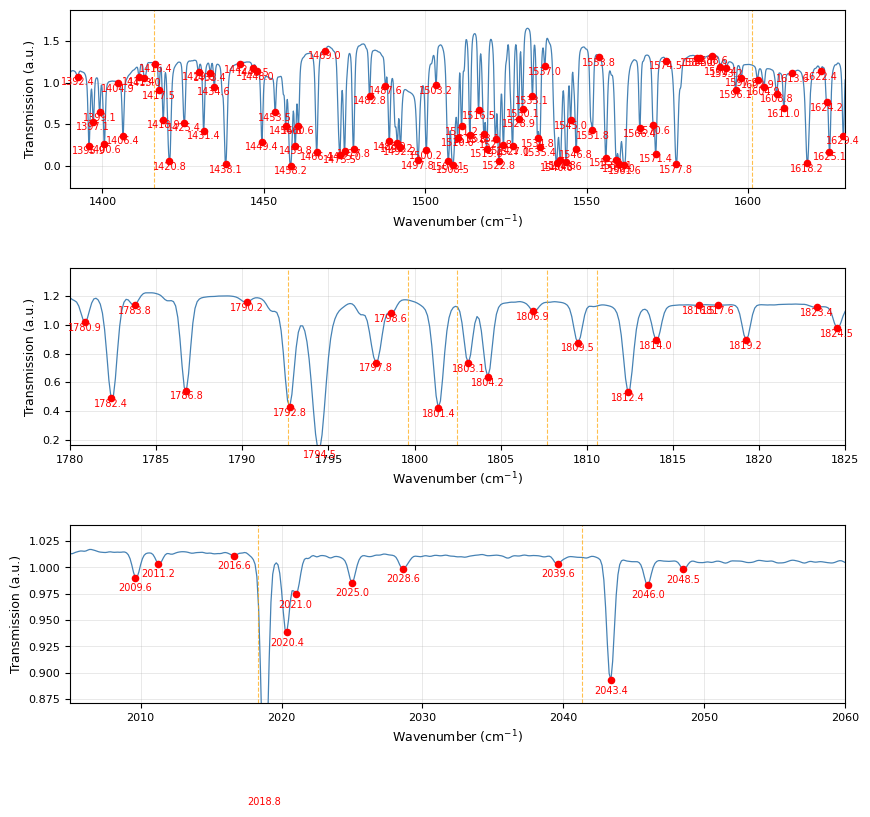

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

DATEI = "1_1_1.asc"

wn_list, it_list = [], []
with open(DATEI, "r", encoding="latin-1") as f:
    daten = False
    for zeile in f:
        z = zeile.strip()
        if z == "#DATA":
            daten = True; continue
        if daten and z:
            t = z.split()
            if len(t) == 2:
                try:
                    wn_list.append(float(t[0]))
                    it_list.append(float(t[1]))
                except ValueError:
                    pass

wn = np.array(wn_list)
it = np.array(it_list)
idx = np.argsort(wn)
wn, it = wn[idx], it[idx]

untergrund = uniform_filter1d(it, size=800)
transmission = it / untergrund

wasser_ref = [1416.08, 1601.20, 1792.65, 1799.61,
              1802.47, 1807.70, 1810.62, 2018.32, 2041.30]

bereiche = [
    (1390, 1630),
    (1780, 1825),
    (2005, 2060),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
plt.subplots_adjust(hspace=0.45)

for ax, (x1, x2) in zip(axes, bereiche):
    maske = (wn >= x1) & (wn <= x2)
    xp, yp = wn[maske], transmission[maske]
    ax.plot(xp, yp, color="steelblue", linewidth=0.9)

    # Minima
    # peaks, _ = find_peaks(-yp, prominence=0.003, distance=3)
    # ax.scatter(xp[peaks], yp[peaks], color="red", s=20, zorder=5)
    # for xi, yi in zip(xp[peaks], yp[peaks]):
    #     ax.text(xi, yi - 0.005, f"{xi:.1f}", fontsize=7,
    #             ha="center", va="top", color="red")

    # Referenzlinien
    for ref in wasser_ref:
        if x1 <= ref <= x2:
            ax.axvline(ref, color="orange", linewidth=0.8, linestyle="--", alpha=0.7)

    ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=9)
    ax.set_ylabel("Transmission (a.u.)", fontsize=9)
    ax.set_xlim(x1, x2)
    p1, p99 = np.percentile(yp, [1, 99])
    m = (p99 - p1) * 0.2
    ax.set_ylim(p1 - m, p99 + m)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.tick_params(labelsize=8)

plt.savefig("wasser_simple.png",
            dpi=120, bbox_inches="tight")
print("Fertig.")